# 6CS012 - Worksheet 3
## Modeling the Neuron: From MCP to Perceptron, Its Learning Algorithm, and Limitations
**Student:** Sambriddhi Dawadi | **ID:** 2331203

---
## Section 3 — MCP Neurons
### Task 1: Implementation of MCP Neurons

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND gate using a McCulloch-Pitts neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1 — element-wise sum of the two input arrays
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 — apply threshold: output 1 if sum >= T, else 0
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron


# --- Sample usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2   # AND threshold: both inputs must fire

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate | inputs X1={X1}, X2={X2} | T={T}")
print(f"Output  : {result_and}")
print(f"Expected: [0, 0, 0, 1]")

AND gate | inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | T=2
Output  : [0, 0, 0, 1]
Expected: [0, 0, 0, 1]


In [9]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR gate using a McCulloch-Pitts neuron.

    Arguments:
        X1 (list): Binary input array.
        X2 (list): Binary input array.
        T  (int) : Threshold value.

    Returns:
        state_neuron (list): Output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1 — element-wise sum
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 — apply threshold
    state_neuron = [1 if s >= T else 0 for s in sums]

    return state_neuron


# --- Sample usage ---
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1   # OR threshold: at least one input must fire

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate  | inputs X1={X1}, X2={X2} | T={T}")
print(f"Output  : {result_or}")
print(f"Expected: [0, 1, 1, 1]")

OR gate  | inputs X1=[0, 0, 1, 1], X2=[0, 1, 0, 1] | T=1
Output  : [0, 1, 1, 1]
Expected: [0, 1, 1, 1]


In [10]:
# Demonstration: XOR using two MCP neurons
def MCP_Neurons_XOR(X1, X2):
    """
    XOR using two MCP neurons:
      - Neuron 1: OR  (T=1)
      - Neuron 2: AND (T=2)
      - Output  : OR AND (NOT AND)
    """
    or_out  = MCP_Neurons_OR(X1,  X2, T=1)
    and_out = MCP_Neurons_AND(X1, X2, T=2)
    state_neuron = [1 if (o == 1 and a == 0) else 0
                    for o, a in zip(or_out, and_out)]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
print(f"XOR result : {MCP_Neurons_XOR(X1, X2)}")
print(f"Expected   : [0, 1, 1, 0]")

XOR result : [0, 1, 1, 0]
Expected   : [0, 1, 1, 0]


#### Step 2 — Load the Dataset

In [11]:
# Load dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values   # shape: (n_samples, 784)
y = df_0_1["label"].values                  # shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)


#### Visualize the Dataset

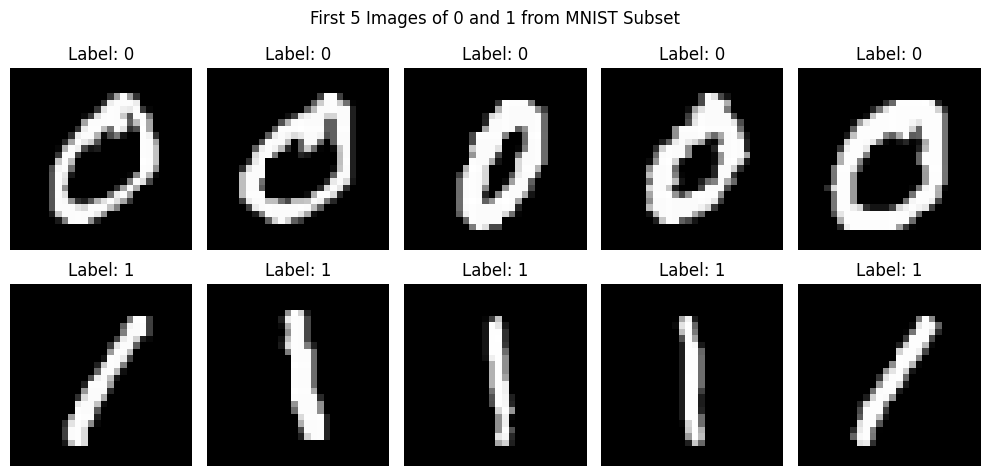

In [12]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

#### Step 3 — Initialize Weights and Bias

In [13]:
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

#### Step 4 — Decision Function (Activation / Step Function)

In [14]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels for input data using the step activation function.

    Parameters:
        X       : ndarray of shape (n_samples, n_features)
        weights : ndarray of shape (n_features,)
        bias    : scalar

    Returns:
        y_pred_all : ndarray of shape (n_samples,) with values in {0, 1}
    """
    # Compute the net weighted input for every sample at once (vectorised)
    # predictions[i] = dot(X[i], weights) + bias
    predictions = np.dot(X, weights) + bias

    # Step (Heaviside) activation: 1 if z >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

#### Step 5 — Perceptron Learning Algorithm

In [15]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : ndarray (n_samples, n_features) — input features
        y             : ndarray (n_samples,)            — true labels {0, 1}
        weights       : ndarray (n_features,)           — initial weights
        bias          : scalar                          — initial bias
        learning_rate : float                           — η (step size)
        epochs        : int                             — max training iterations

    Returns:
        weights  : updated weight vector
        bias     : updated bias
        accuracy : fraction of correctly classified training samples (final epoch)
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        convergence_flag = True          # assume converged until a misclassification is found
        correct          = 0

        for i in range(n_samples):
            # --- Forward pass ---
            # Compute weighted sum for sample i
            # z = w · x_i + b
            z = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_hat = 1 if z >= 0 else 0

            # --- Weight update (only on misclassification) ---
            if y_hat != y[i]:
                error = y[i] - y_hat            # +1 or -1

                # Update each weight: w_j ← w_j + η * error * x_j
                weights = weights + learning_rate * error * X[i]

                # Update bias: b ← b + η * error  (bias input x_0 = 1 always)
                bias    = bias    + learning_rate * error

                convergence_flag = False         # at least one update happened
            else:
                correct += 1

        # --- Early stopping if perfectly classified ---
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}.")
            accuracy = 1.0
            return weights, bias, accuracy

    # Compute final accuracy after all epochs
    y_pred_final = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy     = np.mean(y_pred_final == y)

    return weights, bias, accuracy

#### Step 6 — Train the Perceptron

In [16]:
# Re-initialise to ensure a clean run
weights       = np.zeros(X.shape[1])
bias          = 0
learning_rate = 0.1
epochs        = 100

weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"Final Training Accuracy (0 vs 1): {accuracy:.4f}")

Converged at epoch 13.
Final Training Accuracy (0 vs 1): 1.0000


#### Step 7 — Visualize Misclassified Images

In [17]:
# Final predictions
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Identify misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    rows   = (n_show + 4) // 5   # up to 2 rows of 5
    fig, axes = plt.subplots(rows, 5, figsize=(10, rows * 2.5))
    axes = axes.flat

    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}, True:{y[idx]}", fontsize=8)
        ax.axis("off")

    # Hide unused subplot slots
    for ax in list(axes)[n_show:]:
        ax.set_visible(False)

    plt.suptitle(f"Misclassified Images — 0 vs 1 ({len(misclassified_idx)} total)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


---
## Section 4.4 — Task 3: Perceptron for 3 vs 5 Classification

In [19]:
# ── Step 1: Load dataset ────────────────────────────────────────────────────
df_3_5 = pd.read_csv("/content/mnist_0_and_1.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

# Convert labels to binary: 3 → 0, 5 → 1
# This is required because the perceptron step function outputs {0,1}
y_35_binary = np.where(y_35 == 5, 1, 0)

print("Feature matrix shape:", X_35.shape)
print("Label vector shape  :", y_35_binary.shape)
print("Unique original labels:", np.unique(y_35))

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)
Unique original labels: [0 1]


Error: Not enough images to plot.


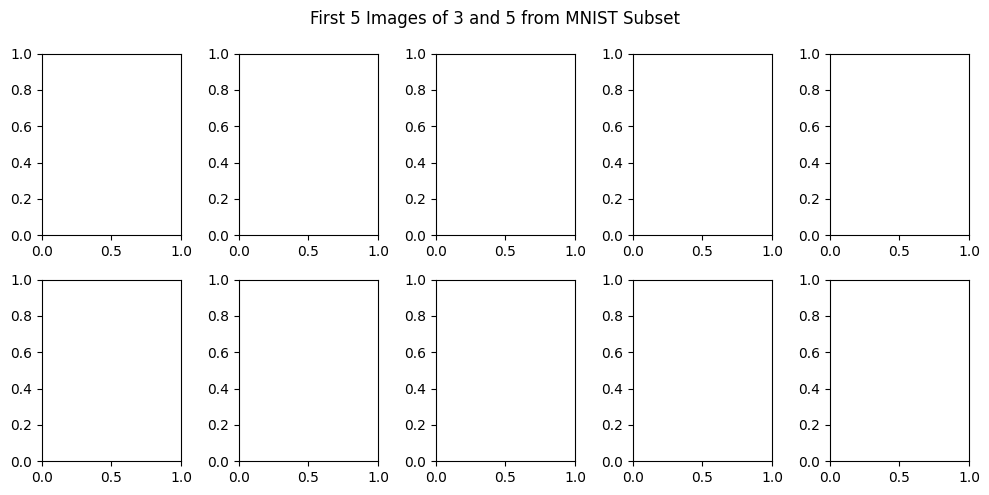

In [20]:
# ── Step 2: Visualize ───────────────────────────────────────────────────────
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to plot.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [21]:
# ── Step 3: Initialize weights ──────────────────────────────────────────────
weights_35       = np.zeros(X_35.shape[1])
bias_35          = 0
learning_rate_35 = 0.1
epochs_35        = 100

In [22]:
# ── Step 4 & 5: Train perceptron ────────────────────────────────────────────
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary,
    weights_35, bias_35,
    learning_rate=learning_rate_35,
    epochs=epochs_35
)
print(f"Final Training Accuracy (3 vs 5): {accuracy_35:.4f}")

Converged at epoch 2.
Final Training Accuracy (3 vs 5): 1.0000


In [23]:
# ── Step 6: Visualize misclassified images ──────────────────────────────────
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35      = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy_35:.4f}")

# Recover original labels for readable plot titles
y_pred_label = np.where(y_pred_35 == 1, 5, 3)
y_true_label = y_35   # original labels

misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    n_show = min(10, len(misclassified_idx_35))
    rows   = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(10, rows * 2.5))
    axes = axes.flat

    for ax, idx in zip(axes, misclassified_idx_35[:n_show]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred_label[idx]}, True:{y_true_label[idx]}", fontsize=8)
        ax.axis("off")

    for ax in list(axes)[n_show:]:
        ax.set_visible(False)

    plt.suptitle(f"Misclassified Images — 3 vs 5 ({len(misclassified_idx_35)} total)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy (3 vs 5): 1.0000
All images were correctly classified!
